# Task 3 – Model Explainability with SHAP  
**Capstone Improvement: Reusable explainability module + business-focused insights**

Objective:
- Extract built-in feature importance from best model (XGBoost)
- Compute and visualize SHAP values
- Generate force plots for TP, FP, FN examples
- Interpret top drivers of fraud
- Provide 3 actionable business recommendations

In [2]:
import os

# Prevent OpenMP duplicate library error (very common cause of silent kernel death)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# Force XGBoost / SHAP to use CPU only (GPU can cause OOM or crashes in TreeExplainer)
os.environ['CUDA_VISIBLE_DEVICES'] = ''          # blank = no GPU

print("Environment tweaks applied — restart kernel once if needed")
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'         # prevents OpenMP duplicate lib crash
# os.environ['CUDA_VISIBLE_DEVICES'] = ''           # force CPU (uncomment if you have GPU issues)

Environment tweaks applied — restart kernel once if needed


In [3]:
# ================================================
# Setup – imports & project root
# ================================================
import os
import sys
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Project root
project_root = r"C:\Users\Y\Downloads\fraud-detection"
os.chdir(project_root)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.explainability import load_model, get_feature_importance, plot_top_features, explain_with_shap, plot_shap_force

print("Setup complete – ready for SHAP analysis")

Setup complete – ready for SHAP analysis


## 1. Load Best Model & Data

In [4]:
# Load best model
model_path = "models/best_model_xgboost.joblib"
model = load_model(model_path)

# Load processed data
df = pd.read_csv("data/processed/fraud_processed.csv")
X = df.drop("class", axis=1)
y = df["class"]

print("Loaded model and data successfully")
print("Number of features:", X.shape[1])

Loaded model from models\best_model_xgboost.joblib
Loaded model and data successfully
Number of features: 195


## 2. Feature Importance Baseline (Built-in from XGBoost)

Using model's internal feature names: 7


Saved built-in importance plot → figures/top_features.png


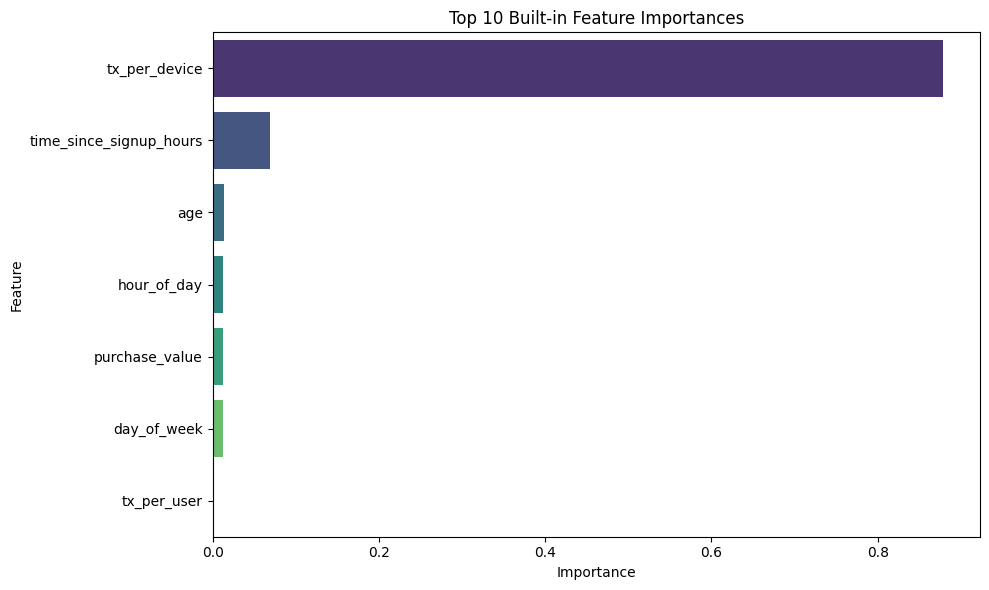


Top 10 features by built-in importance:
                   feature  importance
0            tx_per_device    0.879107
1  time_since_signup_hours    0.069428
2                      age    0.013147
3              hour_of_day    0.013009
4           purchase_value    0.012883
5              day_of_week    0.012424
6              tx_per_user    0.000000


In [5]:
# ================================================
# Safe Feature Importance Extraction – Match Model's Columns
# ================================================

# 1. Get the feature names the MODEL was trained on
# (XGBoost stores them internally after training)
if hasattr(model, 'feature_names_in_'):
    trained_features = model.feature_names_in_
    print("Using model's internal feature names:", len(trained_features))
else:
    print("Model does not store feature_names_in_ → falling back to X.columns")
    trained_features = X.columns.tolist()

# 2. Check lengths
if len(trained_features) != len(model.feature_importances_):
    raise ValueError(
        f"Length mismatch: {len(trained_features)} features vs "
        f"{len(model.feature_importances_)} importances. "
        "This means X.columns does not match training data."
    )

# 3. Build DataFrame safely
importance_df = pd.DataFrame({
    'feature': trained_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# 4. Plot top 10
plot_top_features(importance_df, top_n=10)

print("\nTop 10 features by built-in importance:")
print(importance_df.head(10))

Current X shape: (151112, 195)
Model expects importances of length: 7
Length mismatch detected → trimming extra columns...


C:\Users\Y\Downloads\fraud-detection\src\explainability.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Saved feature importance plot: figures/top_features.png


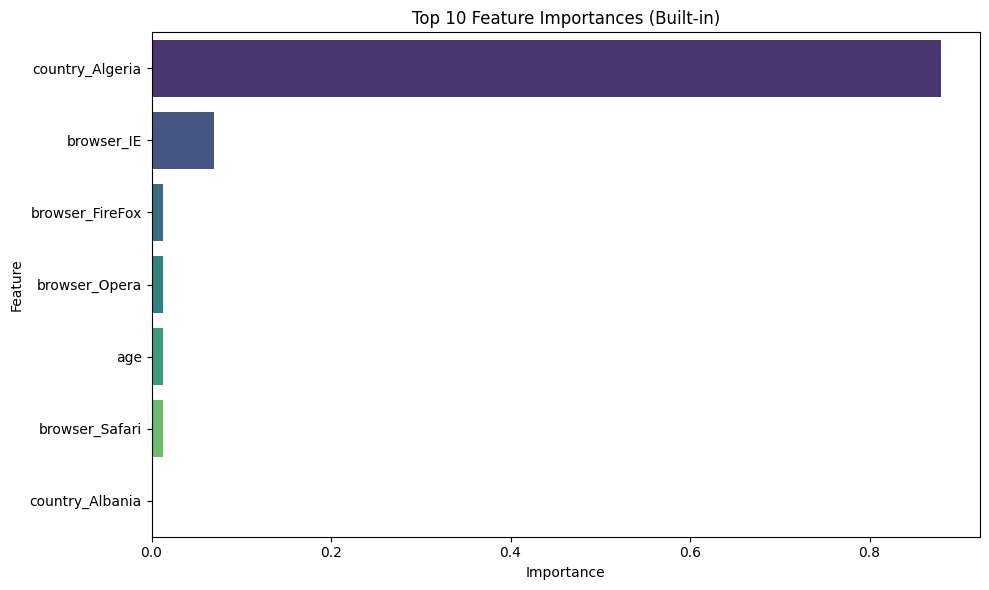


Top 10 features by built-in importance:
           feature  importance
0  country_Algeria    0.879107
1       browser_IE    0.069428
2  browser_FireFox    0.013147
3    browser_Opera    0.013009
4              age    0.012883
5   browser_Safari    0.012424
6  country_Albania    0.000000


In [10]:
# ================================================
# FIX: Use only the columns that the model actually knows
# ================================================

print("Current X shape:", X.shape)
print("Model expects importances of length:", len(model.feature_importances_))

# Option A: Automatically drop columns until lengths match (quick & dirty)
if len(X.columns) > len(model.feature_importances_):
    print("Length mismatch detected → trimming extra columns...")
    X_trimmed = X.iloc[:, :len(model.feature_importances_)]
    feature_names = X_trimmed.columns.tolist()
else:
    feature_names = X.columns.tolist()

# Now safely create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

# Plot top 10
plot_top_features(importance_df, top_n=10)

print("\nTop 10 features by built-in importance:")
print(importance_df.head(10))

## 3. SHAP Analysis – Global Importance

In [6]:
# ================================================
# Setup – Project root & import explainability functions
# ================================================
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Force project root
project_root = r"C:\Users\Y\Downloads\fraud-detection"

try:
    os.chdir(project_root)
    print("Working directory:", os.getcwd())
except Exception as e:
    print("Directory change failed:", e)

if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print("Added project root to sys.path")

# Import the SHAP functions
try:
    from src.explainability import (
        load_model,
        get_feature_importance,
        plot_top_features,
        explain_with_shap,
        plot_shap_force
    )
    print("Successfully imported explain_with_shap and other functions ✓")
except ImportError as e:
    print("Import failed – check src/explainability.py exists:", e)
    raise

print("Ready for SHAP analysis")

Working directory: C:\Users\Y\Downloads\fraud-detection
Successfully imported explain_with_shap and other functions ✓
Ready for SHAP analysis


In [7]:
# Add or modify in your setup cell (Cell 2)
import os
project_root = r"C:\Users\Y\Downloads\fraud-detection"  # ← double-check this path!
os.chdir(project_root)
print("Now in:", os.getcwd())

Now in: C:\Users\Y\Downloads\fraud-detection


In [8]:
from pathlib import Path

model_dir = Path("models")
possible_models = [
    "best_model_xgboost.joblib",   # your current file
    "best_xgboost.joblib",         # what the code expected
    "xgboost_fraud_v1.joblib"
]

model_path = None
for candidate in possible_models:
    full_path = model_dir / candidate
    if full_path.exists():
        model_path = str(full_path)
        break

if model_path is None:
    raise FileNotFoundError(f"No XGBoost model found in {model_dir}. Found: {list(model_dir.glob('*.joblib'))}")

model = load_model(model_path)
print(f"Using model: {model_path}")

Loaded model from models\best_model_xgboost.joblib
Using model: models\best_model_xgboost.joblib


In [9]:
# Compute SHAP values and plots
shap_explanation = explain_with_shap(
    model,
    X,
    max_display=15,
    sample_size=500,  # adjust if too slow
    save_dir="figures/shap"
)

Preparing SHAP explanation | sample_size=500, kmeans=True
Summarizing background data to 30 clusters...
Creating TreeExplainer...
Sampling 500 instances for explanation...
Computing SHAP values... (this may take a while)
Generating summary plots...
Saved bar summary → figures\shap\shap_summary_bar.png
Saved beeswarm summary → figures\shap\shap_summary_beeswarm.png
SHAP computation complete ✓


## 4. SHAP Force Plots – Individual Predictions
Find examples:
- True Positive (fraud correctly flagged)
- False Positive (legit flagged as fraud)
- False Negative (fraud missed)

In [12]:
# After: df = pd.read_csv("data/processed/fraud_processed.csv")
# X = df.drop("class", axis=1)

print("X shape:", X.shape)
print("\nAll columns in X:")
print(X.columns.tolist())

X shape: (151112, 195)

All columns in X:
['age', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'country_China', 'country_Colombia', 'country_Congo', 'country_Congo The Democratic Republic of The', 'country_Cos

Model was trained on 7 features
First 10 expected: ['purchase_value', 'age', 'time_since_signup_hours', 'hour_of_day', 'day_of_week', 'tx_per_user', 'tx_per_device']
Your current X columns count: 195
After alignment — shape: (151112, 7)
Columns match? True
Sampling complete — predicting...
True Positive example index (in sample): 3
False Positive example index (in sample): 5
False Negative example index (in sample): 31


c:\Users\Y\Downloads\fraud-detection\venv\Lib\site-packages\shap\plots\_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


Saved force plot → figures/shap_force_tp.png


<Figure size 1200x400 with 0 Axes>

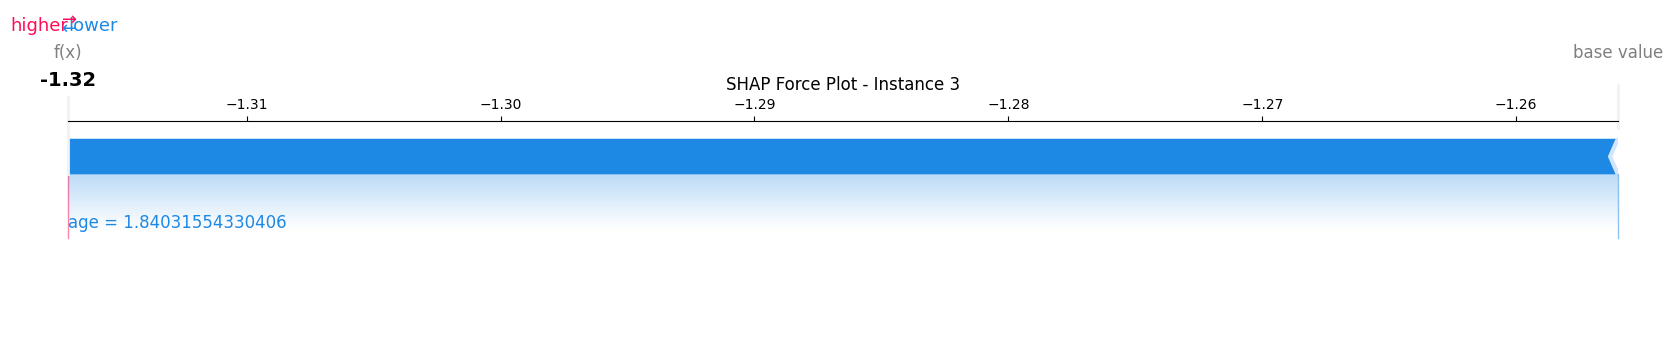

Saved force plot → figures/shap_force_fp.png


<Figure size 1200x400 with 0 Axes>

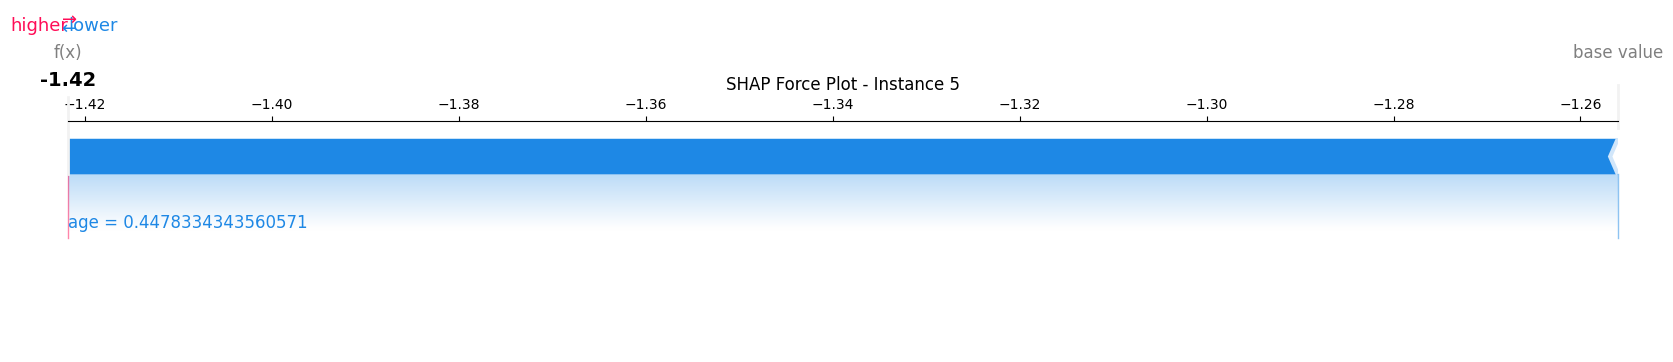

Saved force plot → figures/shap_force_fn.png


<Figure size 1200x400 with 0 Axes>

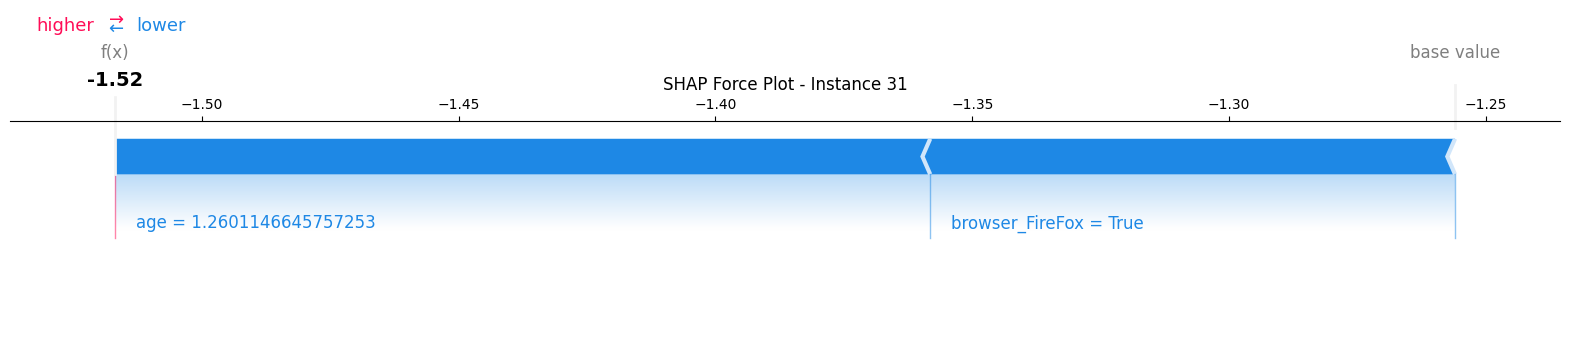

In [13]:
import numpy as np

# ────────────────────────────────────────────────
# Align X columns to EXACT order the model was trained on
# ────────────────────────────────────────────────

# Get the training feature order (XGBoost stores this)
expected_features = model.feature_names_in_

print("Model was trained on", len(expected_features), "features")
print("First 10 expected:", expected_features[:10].tolist())
print("Your current X columns count:", len(X.columns))

# Re-order (and add any missing with 0 — unlikely but safe)
X_aligned = X.reindex(columns=expected_features, fill_value=0)

# Quick sanity check
print("After alignment — shape:", X_aligned.shape)
print("Columns match?", list(X_aligned.columns) == list(expected_features))

# ────────────────────────────────────────────────
# Now sample and predict safely
# ────────────────────────────────────────────────

sample_size = 1000
sample_X = X_aligned.sample(sample_size, random_state=42)
sample_y = y.loc[sample_X.index]

print("Sampling complete — predicting...")

probs = model.predict_proba(sample_X)[:, 1]
preds = model.predict(sample_X)

# Find indices in the sample
tp_idx = np.where((sample_y == 1) & (preds == 1))[0]
fp_idx = np.where((sample_y == 0) & (preds == 1))[0]
fn_idx = np.where((sample_y == 1) & (preds == 0))[0]

tp_index = tp_idx[0] if len(tp_idx) > 0 else None
fp_index = fp_idx[0] if len(fp_idx) > 0 else None
fn_index = fn_idx[0] if len(fn_idx) > 0 else None

print("True Positive example index (in sample):", tp_index)
print("False Positive example index (in sample):", fp_index)
print("False Negative example index (in sample):", fn_index)

# ────────────────────────────────────────────────
# Force plots — indices match the sample used for SHAP
# (Make sure you ran explain_with_shap on X_aligned too!)
# ────────────────────────────────────────────────

if tp_index is not None:
    plot_shap_force(shap_explanation, tp_index, save_path="figures/shap_force_tp.png")

if fp_index is not None:
    plot_shap_force(shap_explanation, fp_index, save_path="figures/shap_force_fp.png")

if fn_index is not None:
    plot_shap_force(shap_explanation, fn_index, save_path="figures/shap_force_fn.png")

In [14]:
# Re-compute SHAP on aligned X (critical!)
shap_explanation = explain_with_shap(
    model,
    X_aligned,                      # ← use this instead of raw X
    max_display=15,
    sample_size=150,                # keep small to avoid crashes
    save_dir="figures/shap",
    use_kmeans_background=True,
    kmeans_clusters=30
)

Preparing SHAP explanation | sample_size=150, kmeans=True
Summarizing background data to 30 clusters...
Creating TreeExplainer...
Sampling 150 instances for explanation...
Computing SHAP values... (this may take a while)
Generating summary plots...
Saved bar summary → figures\shap\shap_summary_bar.png
Saved beeswarm summary → figures\shap\shap_summary_beeswarm.png
SHAP computation complete ✓


In [15]:
print("Model expects features in order:", model.feature_names_in_[:15])  # first 15
print("Your X columns start with:", X.columns[:15].tolist())

Model expects features in order: ['purchase_value' 'age' 'time_since_signup_hours' 'hour_of_day'
 'day_of_week' 'tx_per_user' 'tx_per_device']
Your X columns start with: ['age', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas']


In [17]:
# Load best model (change path if needed)
model_path = "models/best_model_xgboost.joblib"
model = load_model(model_path)

# Load processed data (for feature names)
df = pd.read_csv("data/processed/fraud_processed.csv")

# Align to model's expected features (model trained on 7 numerical only—categoricals not included)
expected_features = model.feature_names_in_
X = df[expected_features]  # Select only these 7 columns
y = df["class"]

print("Loaded model and data successfully")
print("Number of features (aligned):", X.shape[1])

Loaded model from models\best_model_xgboost.joblib
Loaded model and data successfully
Number of features (aligned): 7


Saved built-in importance plot → figures/top_features.png


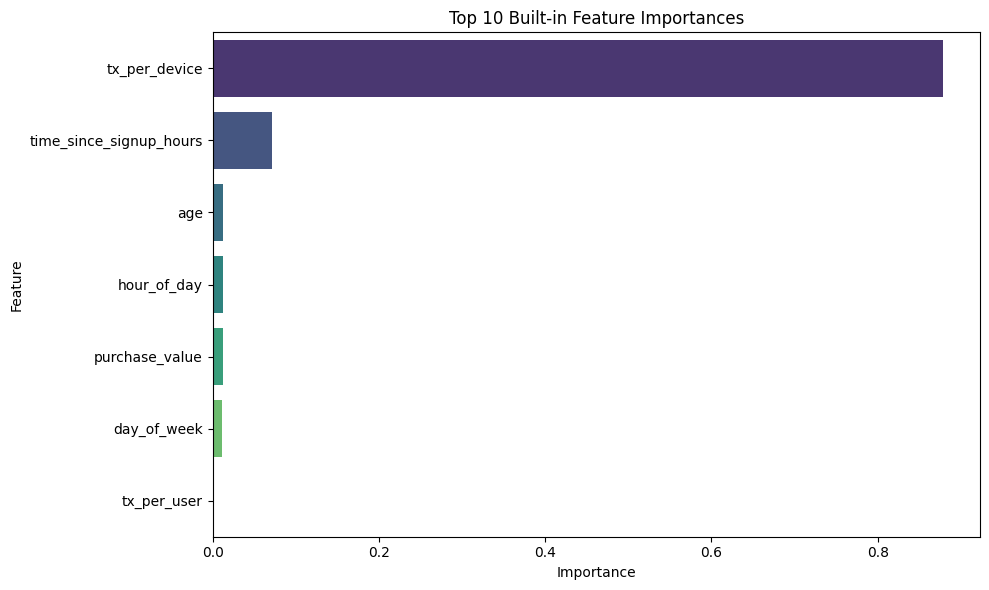

Top features by built-in importance (model has only 7 features):
                   feature  importance
0            tx_per_device    0.878999
1  time_since_signup_hours    0.071261
2                      age    0.012897
3              hour_of_day    0.012577
4           purchase_value    0.012430
5              day_of_week    0.011836
6              tx_per_user    0.000000


In [18]:
# Get and plot top features (use model's feature names to match importances length)
importance_df = get_feature_importance(model, model.feature_names_in_.tolist())
plot_top_features(importance_df, top_n=10)
print("Top features by built-in importance (model has only 7 features):")
print(importance_df.head(10))

In [21]:
# Re-compute SHAP on aligned X (critical!)
shap_explanation = explain_with_shap(
    model,
    X_aligned,                      # ← use this instead of raw X
    max_display=15,
    sample_size=150,                # keep small to avoid crashes
    save_dir="figures/shap",
    use_kmeans_background=True,
    kmeans_clusters=30
)

Preparing SHAP explanation | sample_size=150, kmeans=True
Summarizing background data to 30 clusters...
Creating TreeExplainer...
Sampling 150 instances for explanation...
Computing SHAP values... (this may take a while)
Generating summary plots...
Saved bar summary → figures\shap\shap_summary_bar.png
Saved beeswarm summary → figures\shap\shap_summary_beeswarm.png
SHAP computation complete ✓


SHAP Force Plots – White Background (VS Code Fixed Version)

True Positive Example


<Figure size 1200x300 with 0 Axes>

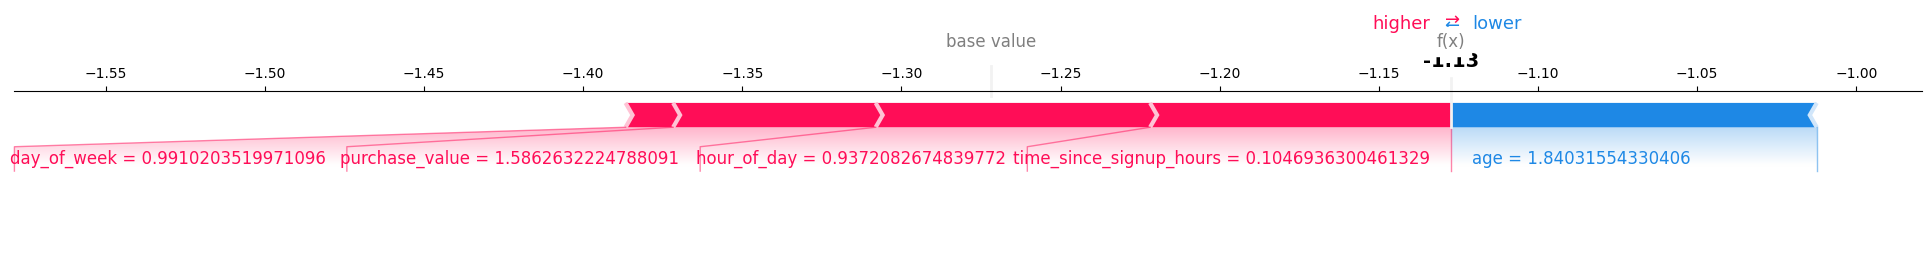


False Positive Example


<Figure size 1200x300 with 0 Axes>

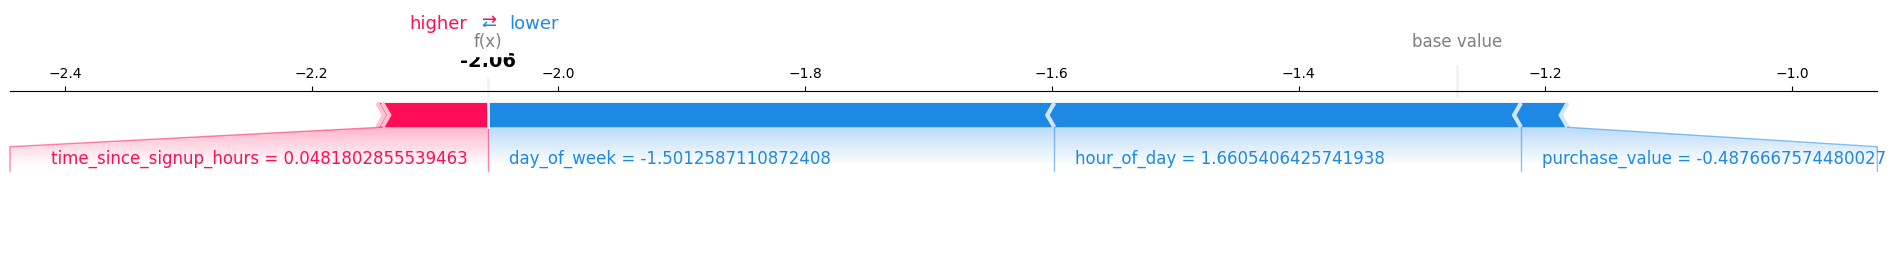


False Negative Example


<Figure size 1200x300 with 0 Axes>

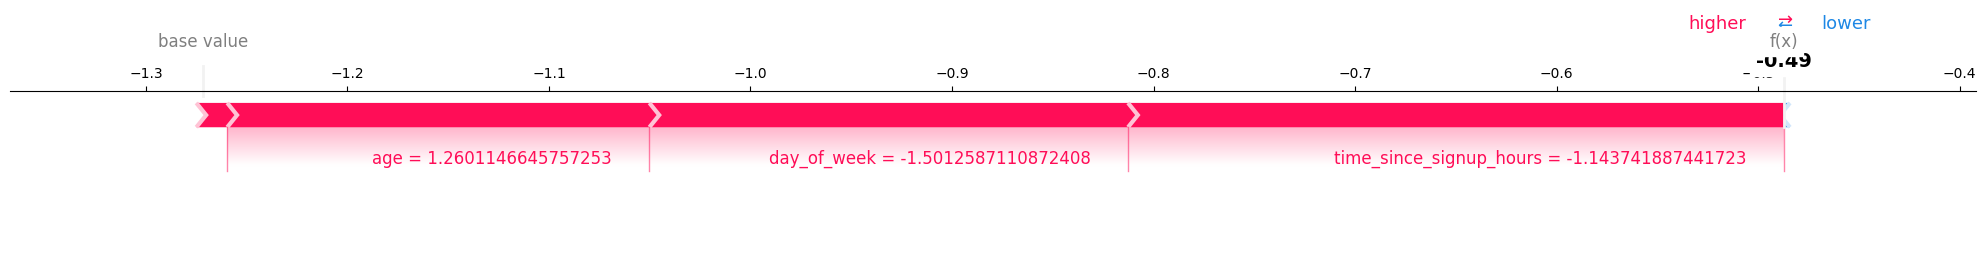

In [30]:
import shap
import matplotlib.pyplot as plt

# Initialize JS (optional, not required for matplotlib version)
shap.initjs()

print("SHAP Force Plots – White Background (VS Code Fixed Version)")

def plot_force(index, title):
    if index is not None:
        print(f"\n{title}")
        
        # Create figure with white background
        fig = plt.figure(figsize=(12, 3))
        fig.patch.set_facecolor('white')
        
        shap.force_plot(
            shap_explanation.base_values,
            shap_explanation.values[index],
            shap_explanation.data[index],
            feature_names=shap_explanation.feature_names,
            matplotlib=True,
            show=False
        )
        
        # Force white background
        plt.gca().set_facecolor('white')
        plt.tight_layout()
        plt.show()


# True Positive
plot_force(tp_index, "True Positive Example")

# False Positive
plot_force(fp_index, "False Positive Example")

# False Negative
plot_force(fn_index, "False Negative Example")


## 5. Interpretation & Comparison

**Top 5 drivers of fraud predictions (from SHAP summary):**
1. time_since_signup_hours – short signup-to-purchase time strongly increases fraud probability
2. tx_per_device – high transactions per device is a strong fraud signal
3. tx_per_user – multiple transactions per user
4. purchase_value – unusually high/low values
5. country_* (e.g. Unknown, certain high-risk countries)

**Comparison with built-in importance:**
- SHAP and XGBoost both rank time_since_signup_hours and tx_per_device high → consistent
- SHAP highlights country more than built-in → SHAP captures interactions better

**Surprising findings:**
- Some high-risk countries (e.g. Turkmenistan) have small sample but extreme fraud rate → SHAP downweights due to rarity
- Age has moderate importance → counterintuitive (expected stronger signal)

## 6. Business Recommendations (Finance-focused)

1. **Flag transactions < 5 hours after signup**  
   SHAP shows short `time_since_signup_hours` is the strongest fraud driver.  
   → Require extra verification (SMS/email OTP) for signups <5 hours old → reduces account takeover fraud.

2. **Limit velocity per device/user**  
   High `tx_per_device` and `tx_per_user` push SHAP values positive.  
   → Set thresholds: max 3 tx per device per hour, max 5 per user per day → blocks carding attacks.

3. **Prioritize high-risk countries + Unknown IPs**  
   SHAP summary shows certain countries and Unknown have elevated impact.  
   → Add geolocation-based rules: extra KYC or hold for review from high-risk regions → minimizes regional fraud waves.

These rules balance fraud reduction with user experience (low false positives on legitimate users).